## Data Distillation by Matching Trajectories

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
class ConvNet(nn.Module):
    def __init__(self, channels=1, num_classes=10):
        super().__init__()

        self.cnn_layers = nn.Sequential(
            nn.Conv2d(channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),            

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                 

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),     
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x_ = self.cnn_layers(x)
        x_ = torch.flatten(x_, start_dim=1) # B x 128
        x_out = self.classifier(x_)
        return x_out

In [3]:
# DATA
device = "cuda" if torch.cuda.is_available() else "cpu"
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='../data/mnist/', train=True, 
                               download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Train and collect trajectories
num_experts = 1
epochs = 5

for expert_idx in range(num_experts):
    print(f"expert_idx {expert_idx}")
    model = ConvNet().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    trajectory = []

    # train model
    model.train()

    # train
    for epoch in range(epochs):
        # save theta
        trajectory.append({k: v.clone().cpu() for k, v in model.state_dict().items()})

        # train
        for x, y in train_loader:
            optimizer.zero_grad()

            x, y = x.to(device), y.to(device)
            y_pred = model(x)

            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()

        if epoch%5 == 0:
            print(f"{epoch} {loss.detach().cpu().numpy()}")

    # save final theta
    trajectory.append({k: v.clone().cpu() for k, v in model.state_dict().items()})

    # save
    torch.save(trajectory, f"mtt/trajectory_{expert_idx}.pt")

expert_idx 0
0 0.006943530403077602


In [32]:
# parameter matching
def compute_distance(params1, params2):
    distance = 0.0
    for (k1, p1), (k2, p2) in zip(params1.items(), params2.items()):
        if p1.is_floating_point() and ('running_mean' not in k1 and 'running_var' not in k1): # exclude batchnorm
            distance += torch.sum((p1 - p2)**2)
    return distance

In [55]:
import torch.nn.functional as F
from torch.func import functional_call
import numpy as np

# LACKS DIFFERENTIABLE AUGMENTATION RIGHT NOW

# student model architecture
student_model = ConvNet(channels=1, num_classes=10)

# load trajectories
expert_trajectories = [torch.load(f"mtt/trajectory_{i}.pt") for i in range(num_experts)]
M = 5 # teacher
N = 4 # student
alpha = torch.tensor(0.0001, device=device, requires_grad=True) # lr

# get synthetic data
n_syn_data = 10
batch_size = 10 # for training student
X_syn, Y_syn = next(iter(train_loader))
X_syn = X_syn[:n_syn_data].to(device).requires_grad_(True)
Y_syn = Y_syn[:n_syn_data].to(device)

distill_optimizer = torch.optim.SGD([{'params': [X_syn], 'lr': 0.01}, 
                                     {'params': [alpha], 'lr': 0.01}])

# line 8
distillation_steps = 500
for d_step in range(distillation_steps):
    # line 9 of algo: choose random expert trajectory
    expert_idx = torch.randint(low = 0, high = len(expert_trajectories), size=(1,))[0]
    expert_trajectory = expert_trajectories[expert_idx]

    # line 10: choose random start epoch
    # choose a value from 0 to len(expert_trajectory) - M
    max_start_epoch = len(expert_trajectory) - M
    start_epoch = np.random.randint(low = 0, high = max_start_epoch)
    print(f"start_epoch {start_epoch}")

    # line of algo: initialize student network parameters
    student_params = {}
    for k, v in expert_trajectory[start_epoch].items():
        if v.is_floating_point() and ('running_mean' not in k and 'running_var' not in k): # exclude batchnorm
            student_params[k] = v.clone().to(device).requires_grad_(True)
        else:
            student_params[k] = v.clone().to(device)

    # line 13
    for n in range(N):
        # line 14-15: sample a minimbatch of synthetic images
        indices = torch.randperm(len(X_syn))[:batch_size]
        x_syn, y_syn = X_syn[indices], Y_syn[indices]

        # line 16-17: update student network parameters
        out = functional_call(student_model, student_params, x_syn)

        # compute loss
        loss = F.cross_entropy(out, y_syn)
        print("Inner loss:", loss.item())

        # compute gradients wrt student params
        # we need create_graph = True so that we still have the graph going back to the dataset (history of gradients)
        trainable_params = {k: v for k, v in student_params.items() if v.requires_grad}
        # pass trainable parameters to autograd
        grads = torch.autograd.grad(loss, trainable_params.values(), create_graph=True)        

        # perform manual weight update
        # we update the parameters and also keep building the computtion graph N times
        # essentially we need to backpropagate through "time" or gradient updates as well
        # in order for us to get to t=0 synthetic data
        updated_params = dict(student_params)
        count_trainable_params_updated = 0
        for (name, param), grad in zip(trainable_params.items(), grads):
            updated_params[name] = param - alpha * grad
            count_trainable_params_updated += 1
        print(f"trainable params layers updated {count_trainable_params_updated}")
        student_params = updated_params

    # Line 20: loss between student and expert/teacher params
    distill_optimizer.zero_grad()
    teacher_params_before = {k: v.clone().to(device) for k, v in expert_trajectory[start_epoch].items()}
    teacher_params_after = {k: v.clone().to(device) for k, v in expert_trajectory[start_epoch + M].items()}

    loss_num = compute_distance(student_params, teacher_params_after)
    loss_denom = compute_distance(teacher_params_before, teacher_params_after)
    loss = loss_num / loss_denom
    print(f"Outer loss: {loss_num:.6f} / {loss_denom:.6f}")
    print("Outer loss:", loss.item())
    print(f"alpha {alpha}")
    print()
    loss.backward()
    distill_optimizer.step()



start_epoch 0
Inner loss: 2.266380548477173
trainable params layers updated 18
Inner loss: 2.2370126247406006
trainable params layers updated 18
Inner loss: 2.2084622383117676
trainable params layers updated 18
Inner loss: 2.1807401180267334
trainable params layers updated 18
Outer loss: 48.461025 / 48.467522
Outer loss: 0.9998659491539001
alpha 9.999999747378752e-05

start_epoch 0
Inner loss: 2.266380786895752
trainable params layers updated 18
Inner loss: 0.8979684114456177
trainable params layers updated 18
Inner loss: 0.3655931353569031
trainable params layers updated 18
Inner loss: 0.19346246123313904
trainable params layers updated 18
Outer loss: 48.050030 / 48.467522
Outer loss: 0.9913861751556396
alpha 0.013447505421936512

start_epoch 0
Inner loss: 2.2663803100585938
trainable params layers updated 18
Inner loss: 0.8433250188827515
trainable params layers updated 18
Inner loss: 0.3200721740722656
trainable params layers updated 18
Inner loss: 0.15513107180595398
trainable para

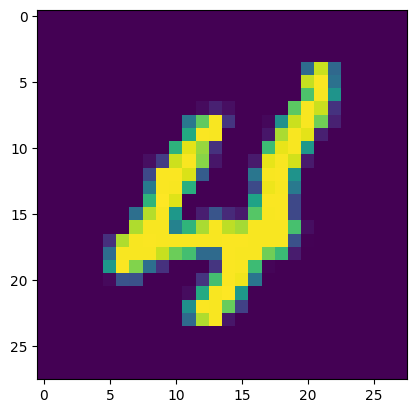

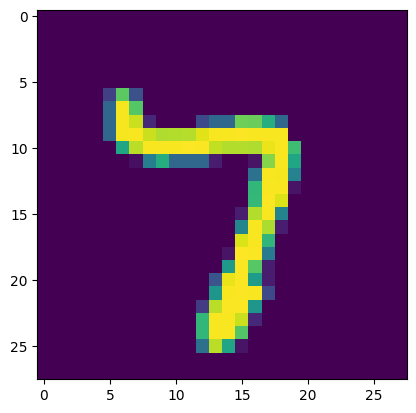

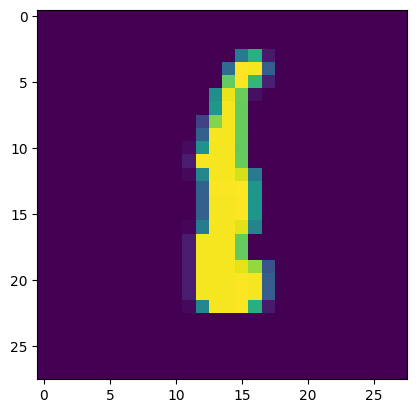

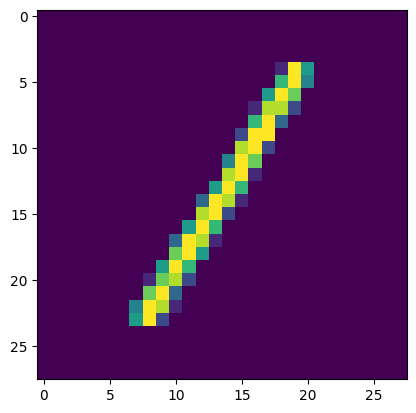

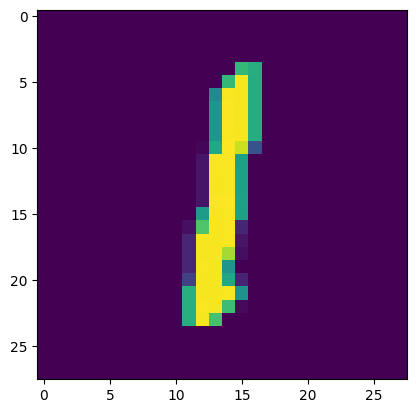

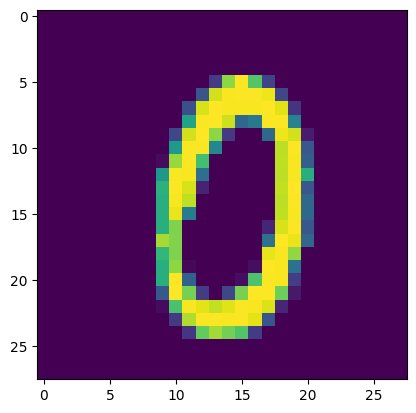

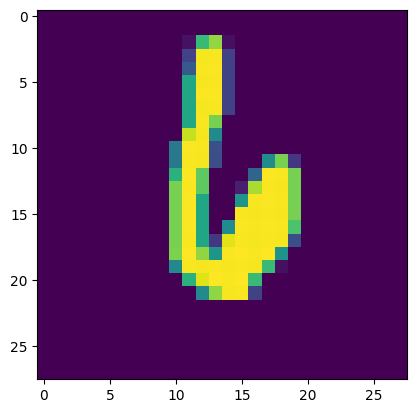

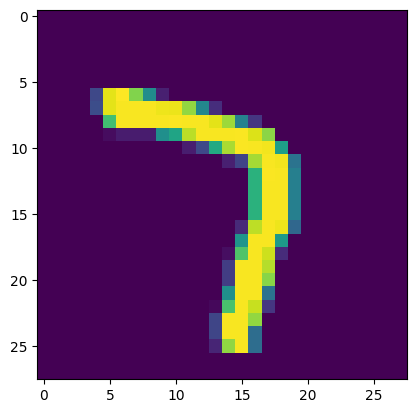

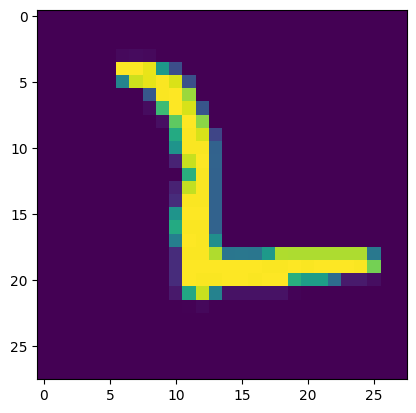

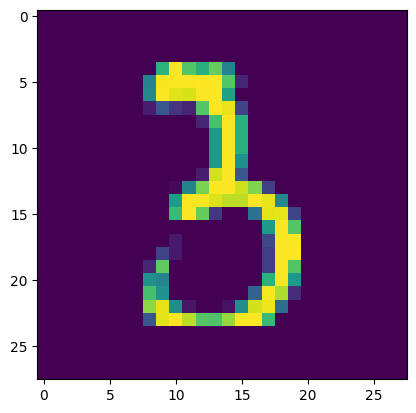

In [60]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.imshow(X_syn[i].squeeze().detach().cpu().numpy())
    plt.show()